In [ ]:
import os
import pandas as pd

DATASET_PATH = "C:/Users/pc/Desktop/Emotion_detector/audio_emotion_detection/dataset/speech_dataset"

audio_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(".wav"):
            file_path = os.path.join(root, file)
            
            folder_name = os.path.basename(root)
            
            emotion = folder_name.split("_", 1)[1].lower()
            
            if emotion == "pleasant_surprised":
                emotion = "surprise"
            
            audio_files.append({
                "path": file_path,
                "emotion": emotion,
                "speaker": file.split("_")[0]
            })

df = pd.DataFrame(audio_files)

print("Total audio files:", len(df))
print("\nEmotion distribution:")
if "emotion" in df.columns:
    print(df["emotion"].value_counts())
else:
    print("No audio files found. Check DATASET_PATH:")
    print(os.path.abspath(DATASET_PATH))

print("\nSpeaker distribution:")
if "speaker" in df.columns and not df.empty:
    print(df["speaker"].value_counts())
else:
    print("No speaker data found. Check DATASET_PATH:")
    print(os.path.abspath(DATASET_PATH))

print("\nFirst 10 samples:")
display(df.head(10))

Total audio files: 2800

Emotion distribution:
emotion
angry                400
disgust              400
fear                 400
happy                400
neutral              400
sad                  400
pleasant_surprise    200
surprise             200
Name: count, dtype: int64

Speaker distribution:
speaker
YAF    1400
OAF    1399
OA        1
Name: count, dtype: int64

First 10 samples:


,path,emotion,speaker
0,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
1,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
2,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
3,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
4,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
5,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
6,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
7,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
8,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF
9,C:/Users/pc/Desktop/Emotion_detector/audio_emo...,angry,OAF


In [21]:
print("Total audio files:", len(df))

print("\n--- Emotion Distribution ---")
print(df["emotion"].value_counts().sort_index())

print("\n--- Speaker Distribution ---")
print(df["speaker"].value_counts())

print("\n--- Emotion × Speaker ---")
print(pd.crosstab(df["emotion"], df["speaker"]))

Total audio files: 2800

--- Emotion Distribution ---
emotion
angry                400
disgust              400
fear                 400
happy                400
neutral              400
pleasant_surprise    200
sad                  400
surprise             200
Name: count, dtype: int64

--- Speaker Distribution ---
speaker
YAF    1400
OAF    1399
OA        1
Name: count, dtype: int64

--- Emotion × Speaker ---
speaker            OA  OAF  YAF
emotion                        
angry               0  200  200
disgust             0  200  200
fear                0  200  200
happy               0  200  200
neutral             1  199  200
pleasant_surprise   0  200    0
sad                 0  200  200
surprise            0    0  200


In [22]:
df["speaker"] = df["speaker"].replace({"OA": "OAF"})

df["emotion"] = df["emotion"].replace({
    "pleasant_surprise": "surprise",
    "pleasant_surprised": "surprise"
})

print("Total audio files:", len(df))

print("\n--- Emotion Distribution ---")
print(df["emotion"].value_counts().sort_index())

print("\n--- Speaker Distribution ---")
print(df["speaker"].value_counts())

print("\n--- Emotion × Speaker ---")
print(pd.crosstab(df["emotion"], df["speaker"]))

Total audio files: 2800

--- Emotion Distribution ---
emotion
angry       400
disgust     400
fear        400
happy       400
neutral     400
sad         400
surprise    400
Name: count, dtype: int64

--- Speaker Distribution ---
speaker
OAF    1400
YAF    1400
Name: count, dtype: int64

--- Emotion × Speaker ---
speaker   OAF  YAF
emotion           
angry     200  200
disgust   200  200
fear      200  200
happy     200  200
neutral   200  200
sad       200  200
surprise  200  200


In [23]:
import librosa

sample_path = df.iloc[0]["path"]

audio, sample_rate = librosa.load(sample_path, sr=None)

print("Sample file:", sample_path)
print("Sample rate:", sample_rate, "Hz")
print("Duration:", len(audio) / sample_rate, "seconds")
print("Audio shape:", audio.shape)

Sample file: C:/Users/pc/Desktop/Emotion_detector/audio_emotion_detection/src/speech_dataset\OAF_angry\OAF_back_angry.wav
Sample rate: 24414 Hz
Duration: 1.5390349799295486 seconds
Audio shape: (37574,)


In [24]:
import librosa
import numpy as np

def extract_mfcc(file_path, max_pad_len=130):
    audio, sr = librosa.load(file_path, sr=22050)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(
            mfcc,
            pad_width=((0, 0), (0, pad_width)),
            mode="constant"
        )
    else:
        mfcc = mfcc[:, :max_pad_len]

    return mfcc

In [25]:
test_mfcc = extract_mfcc(df.iloc[0]["path"])

print("MFCC shape:", test_mfcc.shape)
print("Minimum:", test_mfcc.min())
print("Maximum:", test_mfcc.max())

MFCC shape: (40, 130)
Minimum: -601.3875
Maximum: 143.38315


In [26]:
X = []
y = []

for _, row in df.iterrows():
    mfcc = extract_mfcc(row["path"])
    
    X.append(mfcc)
    y.append(row["emotion"])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (2800, 40, 130)
y shape: (2800,)
Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2240, 40, 130)
X_test : (560, 40, 130)
y_train: (2240,)
y_test : (560,)


In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

X_train: (1792, 40, 130)
X_val  : (448, 40, 130)
X_test : (560, 40, 130)

y_train: (1792,)
y_val  : (448,)
y_test : (560,)


In [29]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (1792, 40, 130, 1)
X_val  : (448, 40, 130, 1)
X_test : (560, 40, 130, 1)


In [30]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

y_train_cat = to_categorical(y_train_encoded, num_classes=7)
y_val_cat = to_categorical(y_val_encoded, num_classes=7)
y_test_cat = to_categorical(y_test_encoded, num_classes=7)

print("\ny_train_cat:", y_train_cat.shape)
print("y_val_cat  :", y_val_cat.shape)
print("y_test_cat :", y_test_cat.shape)

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']

y_train_cat: (1792, 7)
y_val_cat  : (448, 7)
y_test_cat : (560, 7)


In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

audio_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(40, 130, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(7, activation="softmax")
])

audio_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

audio_model.summary()

c:\Users\pc\Desktop\Emotion_detector\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 29, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 29, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 14, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 14, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       688,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 782,727 (2.99 MB)

 Trainable params: 782,279 (2.98 MB)

 Non-trainable params: 448 (1.75 KB)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = audio_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 460ms/step - accuracy: 0.7383 - loss: 0.9183 - val_accuracy: 0.9955 - val_loss: 0.0458 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 431ms/step - accuracy: 0.9503 - loss: 0.1346 - val_accuracy: 0.9799 - val_loss: 0.0457 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 450ms/step - accuracy: 0.9643 - loss: 0.1069 - val_accuracy: 0.9978 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 447ms/step - accuracy: 0.9715 - loss: 0.0846 - val_accuracy: 0.9978 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 438ms/step - accuracy: 0.9827 - loss: 0.0476 - val_accuracy: 0.9978 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.9900 - loss: 0.0357 - val_accuracy: 1.0000 - val_loss: 7.9021e-04 - learning_rate: 0.0010
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 577ms/step - accuracy: 0.9894 - loss

In [33]:
test_loss, test_accuracy = audio_model.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9982 - loss: 0.0095

Test Loss: 0.0095
Test Accuracy: 0.9982


In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

y_pred_prob = audio_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step
Confusion Matrix:
[[80  0  0  0  0  0  0]
 [ 0 80  0  0  0  0  0]
 [ 0  0 80  0  0  0  0]
 [ 0  0  0 80  0  0  0]
 [ 0  0  0  0 80  0  0]
 [ 0  0  0  0  0 80  0]
 [ 0  1  0  0  0  0 79]]

Classification Report:
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00        80
     disgust       0.99      1.00      0.99        80
        fear       1.00      1.00      1.00        80
       happy       1.00      1.00      1.00        80
     neutral       1.00      1.00      1.00        80
         sad       1.00      1.00      1.00        80
    surprise       1.00      0.99      0.99        80

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560



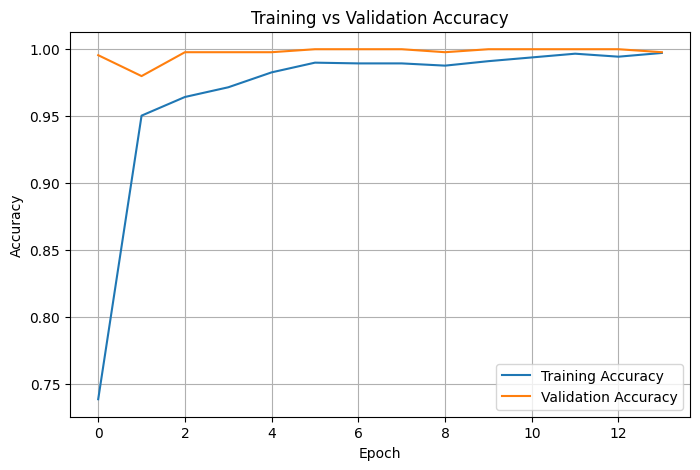

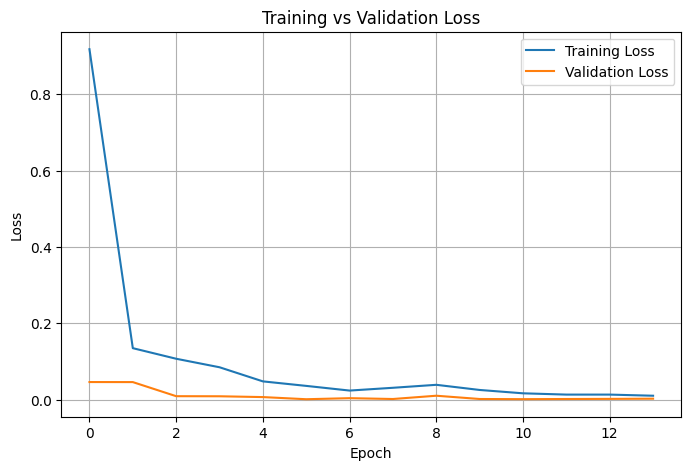

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
audio_model.save("voice_emotion_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [38]:
import json

label_mapping = {
    int(i): label
    for i, label in enumerate(label_encoder.classes_)
}

with open("voice_emotion_labels.json", "w") as f:
    json.dump(label_mapping, f, indent=4)

print(label_mapping)

{0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


In [39]:
import os

print("Model exists:", os.path.exists("voice_emotion_model.keras"))
print("Labels exists:", os.path.exists("voice_emotion_labels.json"))

Model exists: True
Labels exists: True


In [40]:
import tensorflow as tf
import json

model = tf.keras.models.load_model(
    "../model/voice_emotion_model.keras"
)

with open("../model/voice_emotion_labels.json", "r") as f:
    labels = json.load(f)

print("Model loaded successfully!")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Labels:", labels)

Model loaded successfully!
Input shape: (None, 40, 130, 1)
Output shape: (None, 7)
Labels: {'0': 'angry', '1': 'disgust', '2': 'fear', '3': 'happy', '4': 'neutral', '5': 'sad', '6': 'surprise'}


Dataset Shape: (3168, 21)

Columns:
['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label']

Gender Distribution:
label
male      1584
female    1584
Name: count, dtype: int64

Test Accuracy: 98.42%

Classification Report:
              precision    recall  f1-score   support

      female       0.99      0.98      0.98       317
        male       0.98      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



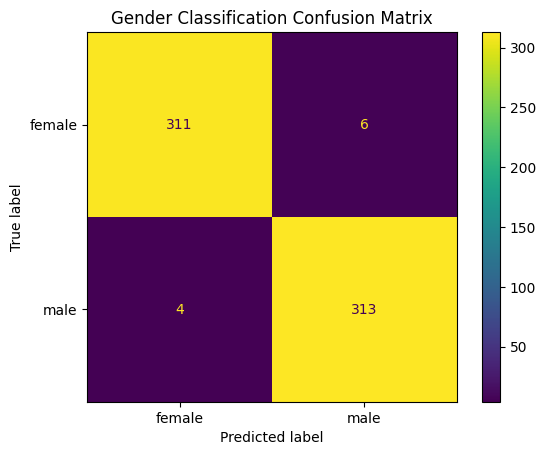


Model saved successfully.
gender_model.pkl
gender_labels.json


In [3]:
import os
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd())))
CSV_PATH = os.path.join(BASE_DIR, "src", "voice.csv")
MODEL_DIR = os.path.join(BASE_DIR, "model")

df = pd.read_csv("C:/Users/pc/Desktop/Emotion_detector/audio_emotion_detection/src/voice.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nGender Distribution:")
print(df["label"].value_counts())

X = df.drop(columns=["label"])
X = X.select_dtypes(include=["number"])

y = df["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

gender_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

gender_model.fit(X_train, y_train)

y_pred = gender_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Gender Classification Confusion Matrix")
plt.show()

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(
    gender_model,
    os.path.join(MODEL_DIR, "gender_model.pkl")
)

with open(
    os.path.join(MODEL_DIR, "gender_labels.json"),
    "w"
) as f:
    json.dump(
        {
            int(i): label
            for i, label in enumerate(label_encoder.classes_)
        },
        f,
        indent=4
    )

print("\nModel saved successfully.")
print("gender_model.pkl")
print("gender_labels.json")